In [16]:
import kagglehub
import shutil
import os
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


path = kagglehub.dataset_download("davidcariboo/player-scores")
print("Downloaded to:", path)

target_dir = os.path.join('data', 'raw', 'player_scores')
os.makedirs(target_dir, exist_ok=True)
shutil.copytree(path, target_dir, dirs_exist_ok=True)
print("Copied to:", target_dir)

Downloaded to: C:\Users\darag\.cache\kagglehub\datasets\davidcariboo\player-scores\versions\602
Copied to: data\raw\player_scores


In [17]:
players = pd.read_csv('data/raw/player_scores/players.csv')
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32601 entries, 0 to 32600
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             32601 non-null  int64  
 1   first_name                            30539 non-null  object 
 2   last_name                             32601 non-null  object 
 3   name                                  32601 non-null  object 
 4   last_season                           32601 non-null  int64  
 5   current_club_id                       32601 non-null  int64  
 6   player_code                           32601 non-null  object 
 7   country_of_birth                      29802 non-null  object 
 8   city_of_birth                         30146 non-null  object 
 9   country_of_citizenship                32218 non-null  object 
 10  date_of_birth                         32554 non-null  object 
 11  sub_position   

In [18]:
print(players['position'].value_counts())

position
Defender      10389
Midfield       9391
Attack         8921
Goalkeeper     3720
Missing         180
Name: count, dtype: int64


In [19]:
print(players['country_of_citizenship'].value_counts().head(10))

country_of_citizenship
Spain          1965
Italy          1887
France         1761
Brazil         1629
England        1588
Ukraine        1497
Russia         1482
Netherlands    1447
Turkey         1424
Germany        1337
Name: count, dtype: int64


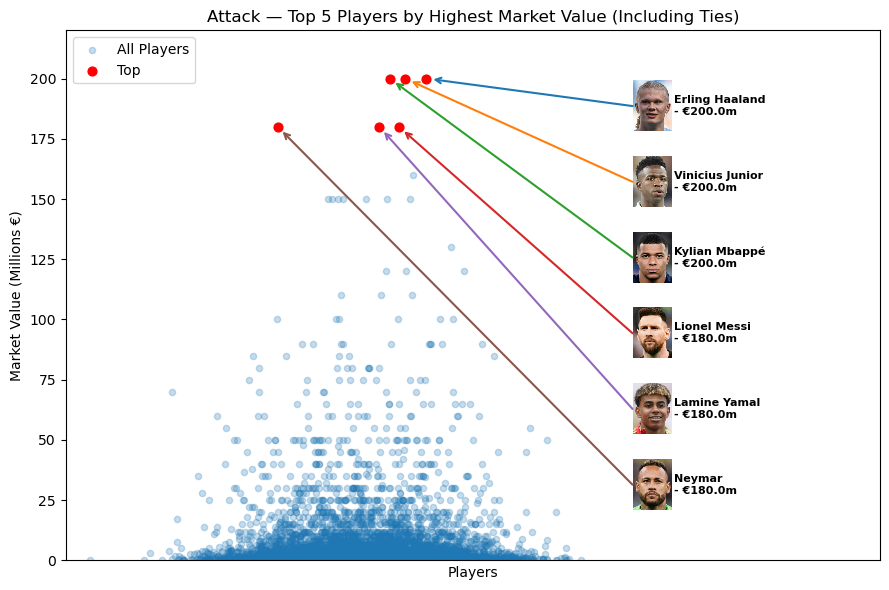

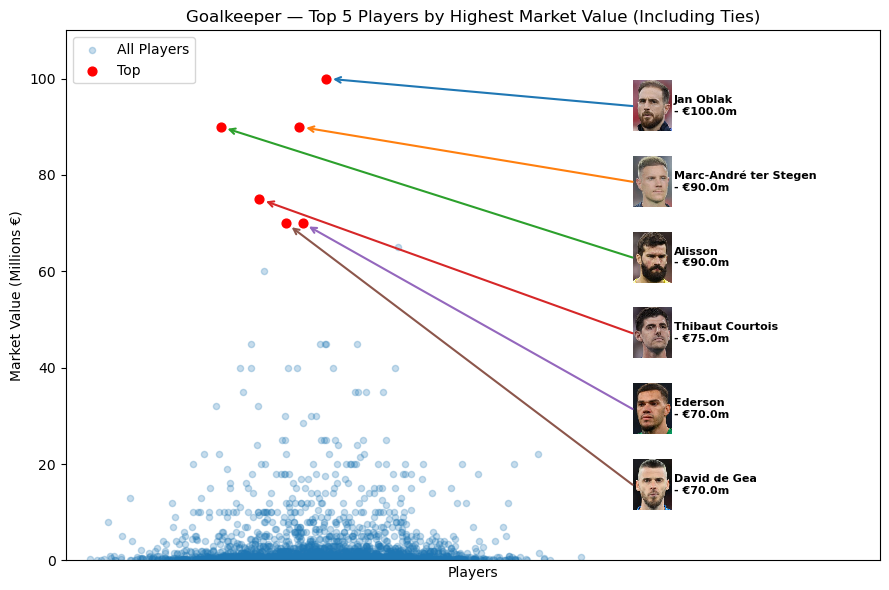

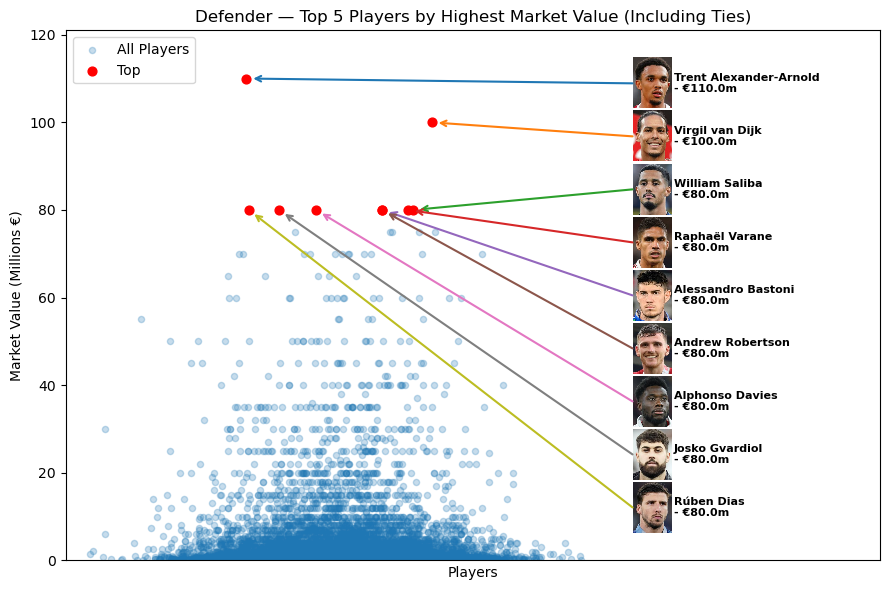

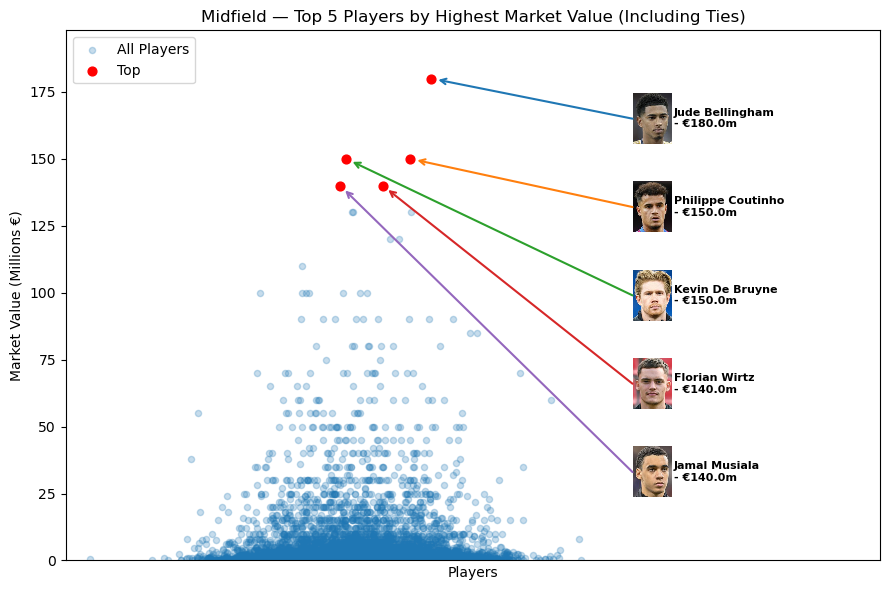

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, HPacker
from urllib.request import urlopen
from PIL import Image

players_plot = players[players['position'] != 'Missing'].copy()
players_plot['pos_code'] = players_plot['position'].astype('category').cat.codes
np.random.seed(0)
players_plot['jitter'] = np.random.normal(0, 0.08, size=len(players_plot))
players_plot['x'] = players_plot['pos_code'] + players_plot['jitter']

positions = players_plot['position'].unique()

colors = plt.cm.tab10.colors

for pos in positions:
    subset = players_plot[players_plot['position'] == pos].copy()
    sorted_subset = subset.sort_values(by=['highest_market_value_in_eur', 'x'], ascending=[False, False])
    if len(sorted_subset) < 5:
        top_players = sorted_subset
    else:
        cutoff_value = sorted_subset.iloc[4]['highest_market_value_in_eur']
        top_players = sorted_subset[sorted_subset['highest_market_value_in_eur'] >= cutoff_value]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(subset['x'], subset['highest_market_value_in_eur'] / 1e6,
               alpha=0.25, s=20, label='All Players')
    ax.scatter(top_players['x'], top_players['highest_market_value_in_eur'] / 1e6,
               color='red', s=40, label='Top')

    y_max = subset['highest_market_value_in_eur'].max() / 1e6
    ax.set_ylim(0, y_max * 1.1)

    top_players = top_players.reset_index(drop=True)

    x_min, x_max = ax.get_xlim()
    margin = (x_max - x_min) * 0.51
    ax.set_xlim(x_min, x_max + margin)
    x_right = x_max + margin * 0.1

    y_lim_min, y_lim_max = ax.get_ylim()
    spacing = y_lim_max / (len(top_players) + 1)

    for i, row in top_players.iterrows():
        y_val = row['highest_market_value_in_eur'] / 1e6
        label = f"{row['name']}\n- €{y_val:1}m"
        text_box = TextArea(label, textprops=dict(color='black', fontsize=8, weight='bold'))
        with urlopen(row['image_url']) as url:
            img = Image.open(url)
            imagebox = OffsetImage(img, zoom=0.2)

        label_box = HPacker(children=[imagebox, text_box], align="center", pad=0, sep=2)

        y_pos = y_lim_max - (i + 1) * spacing
        ab = AnnotationBbox(
            label_box,
            (x_right, y_pos),
            xycoords='data',
            box_alignment=(0, 0.5),
            frameon=False
        )
        ax.add_artist(ab)

        ax.annotate(
            '',
            xy=(row['x'], y_val),
            xytext=(x_right, y_pos),
            arrowprops=dict(
                arrowstyle='->',
                lw=1.5,
                color=colors[i % len(colors)],
                shrinkA=0, shrinkB=5
            )
        )
    
    ax.legend(loc='upper left')
    ax.set_title(f"{pos} — Top 5 Players by Highest Market Value (Including Ties)")
    ax.set_xlabel('Players')
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.set_ylabel('Market Value (Millions €)')
    plot_name = f"{pos}_top_5_players_by_highest_market_value.png"
    plt.savefig(f"../outputs/eda_plots/{plot_name}", dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [21]:
valuations = pd.read_csv('../data/raw/player_scores/player_valuations.csv')
valuations['date'] = pd.to_datetime(valuations['date'])
season_2425 = valuations[valuations['date'] >= '2024-07-01']

latest_2425 = season_2425.sort_values('date').groupby('player_id').last().reset_index()

players = pd.read_csv('../data/raw/player_scores/players.csv')
df = latest_2425.merge(players, on='player_id', how='left')

df = df.rename(columns={'market_value_in_eur': 'market_value_in_eur'})
if 'market_value_in_eur' not in df.columns:
	if 'market_value_in_eur_x' in df.columns:
		df['market_value_in_eur'] = df['market_value_in_eur_x']
	elif 'market_value_in_eur_y' in df.columns:
		df['market_value_in_eur'] = df['market_value_in_eur_y']

df['market_value_millions'] = df['market_value_in_eur'] / 1e6

df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['date'] = pd.to_datetime(df['date'])
df['age'] = (df['date'] - df['date_of_birth']).dt.days / 365.25
df['age'] = df['age'].round(1)

df = df[(df['market_value_millions'] >= 1.0) & (df['age'].between(16, 40))]

print(f"Professional 2024-25 players: {len(df)}")
print("Top 5 most valuable:")
print(df.nlargest(5, 'market_value_millions')[['name', 'age', 'position', 'market_value_millions', 'date']])

Professional 2024-25 players: 3728
Top 5 most valuable:
                 name   age  position  market_value_millions       date
2438  Vinicius Junior  24.5    Attack                  200.0 2024-12-27
2827   Erling Haaland  24.4    Attack                  200.0 2024-12-16
4063  Jude Bellingham  21.5  Midfield                  180.0 2024-12-27
5807     Lamine Yamal  17.5    Attack                  180.0 2024-12-27
2132    Kylian Mbappé  26.3    Attack                  170.0 2025-03-21


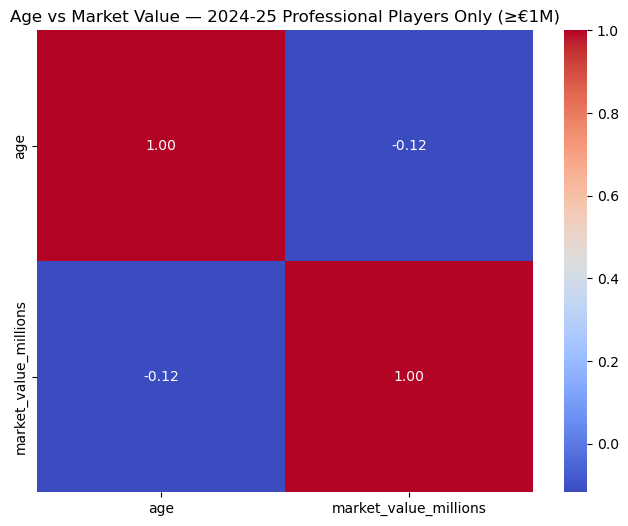

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['age', 'market_value_millions']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',)
plt.title('Age vs Market Value — 2024-25 Professional Players Only (≥€1M)')
plt.xlabel('')
plt.ylabel('')
plt.savefig('../outputs/eda_plots/correlation_2024_25.png', dpi=300, bbox_inches='tight')
plt.show()

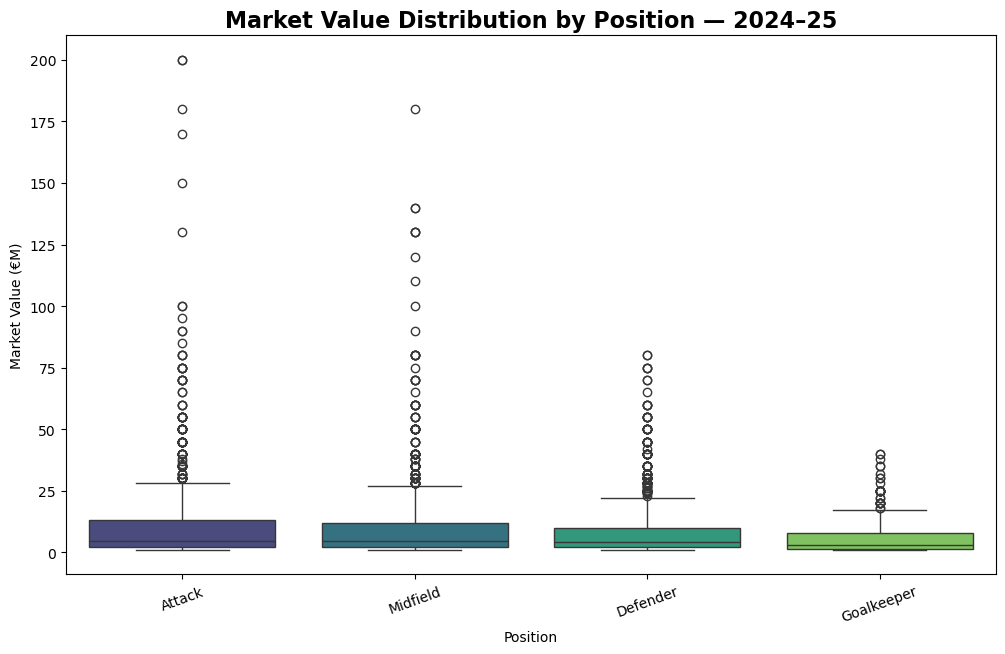

In [23]:
plt.figure(figsize=(12, 7))
order = df.groupby('position')['market_value_millions'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='position', y='market_value_millions', order=order, palette='viridis')
plt.title('Market Value Distribution by Position — 2024–25', fontsize=16, fontweight='bold')
plt.xlabel('Position')
plt.ylabel('Market Value (€M)')
plt.xticks(rotation=20)
plt.savefig('../outputs/eda_plots/value_boxplot_position.png', dpi=300, bbox_inches='tight')
plt.show()

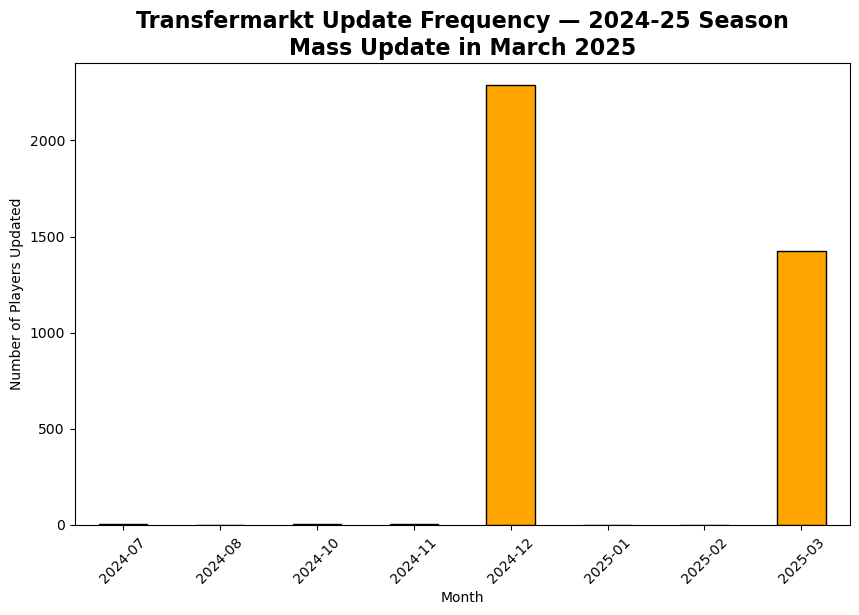

In [24]:
df['month'] = df['date'].dt.strftime('%Y-%m')
updates = df['month'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
updates.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Transfermarkt Update Frequency — 2024-25 Season\nMass Update in March 2025', 
          fontsize=16, fontweight='bold')
plt.ylabel('Number of Players Updated')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.savefig('../outputs/eda_plots/update_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
def get_yearly_deltas(league_id='GB1', start_year=2021, end_year=2024):
    valuations = pd.read_csv('../data/raw/player_scores/player_valuations.csv')
    players = pd.read_csv('../data/raw/player_scores/players.csv')
    
    league_vals = valuations[valuations['player_club_domestic_competition_id'] == league_id]
    
    league_vals['date'] = pd.to_datetime(league_vals['date'])
    league_vals['year'] = league_vals['date'].dt.year
    
    yearly_vals = league_vals.sort_values('date').groupby(['player_id', 'year'])['market_value_in_eur'].last().reset_index()
    
    yearly_vals = yearly_vals.sort_values(['player_id', 'year'])
    yearly_vals['delta_eur'] = yearly_vals.groupby('player_id')['market_value_in_eur'].diff()
    yearly_vals['delta_millions'] = yearly_vals['delta_eur'] / 1e6
    
    yearly_vals = yearly_vals.merge(players[['player_id', 'name']], on='player_id', how='left')
    
    yearly_deltas = yearly_vals[yearly_vals['year'].between(start_year, end_year)].dropna(subset=['delta_millions'])
    
    return yearly_deltas

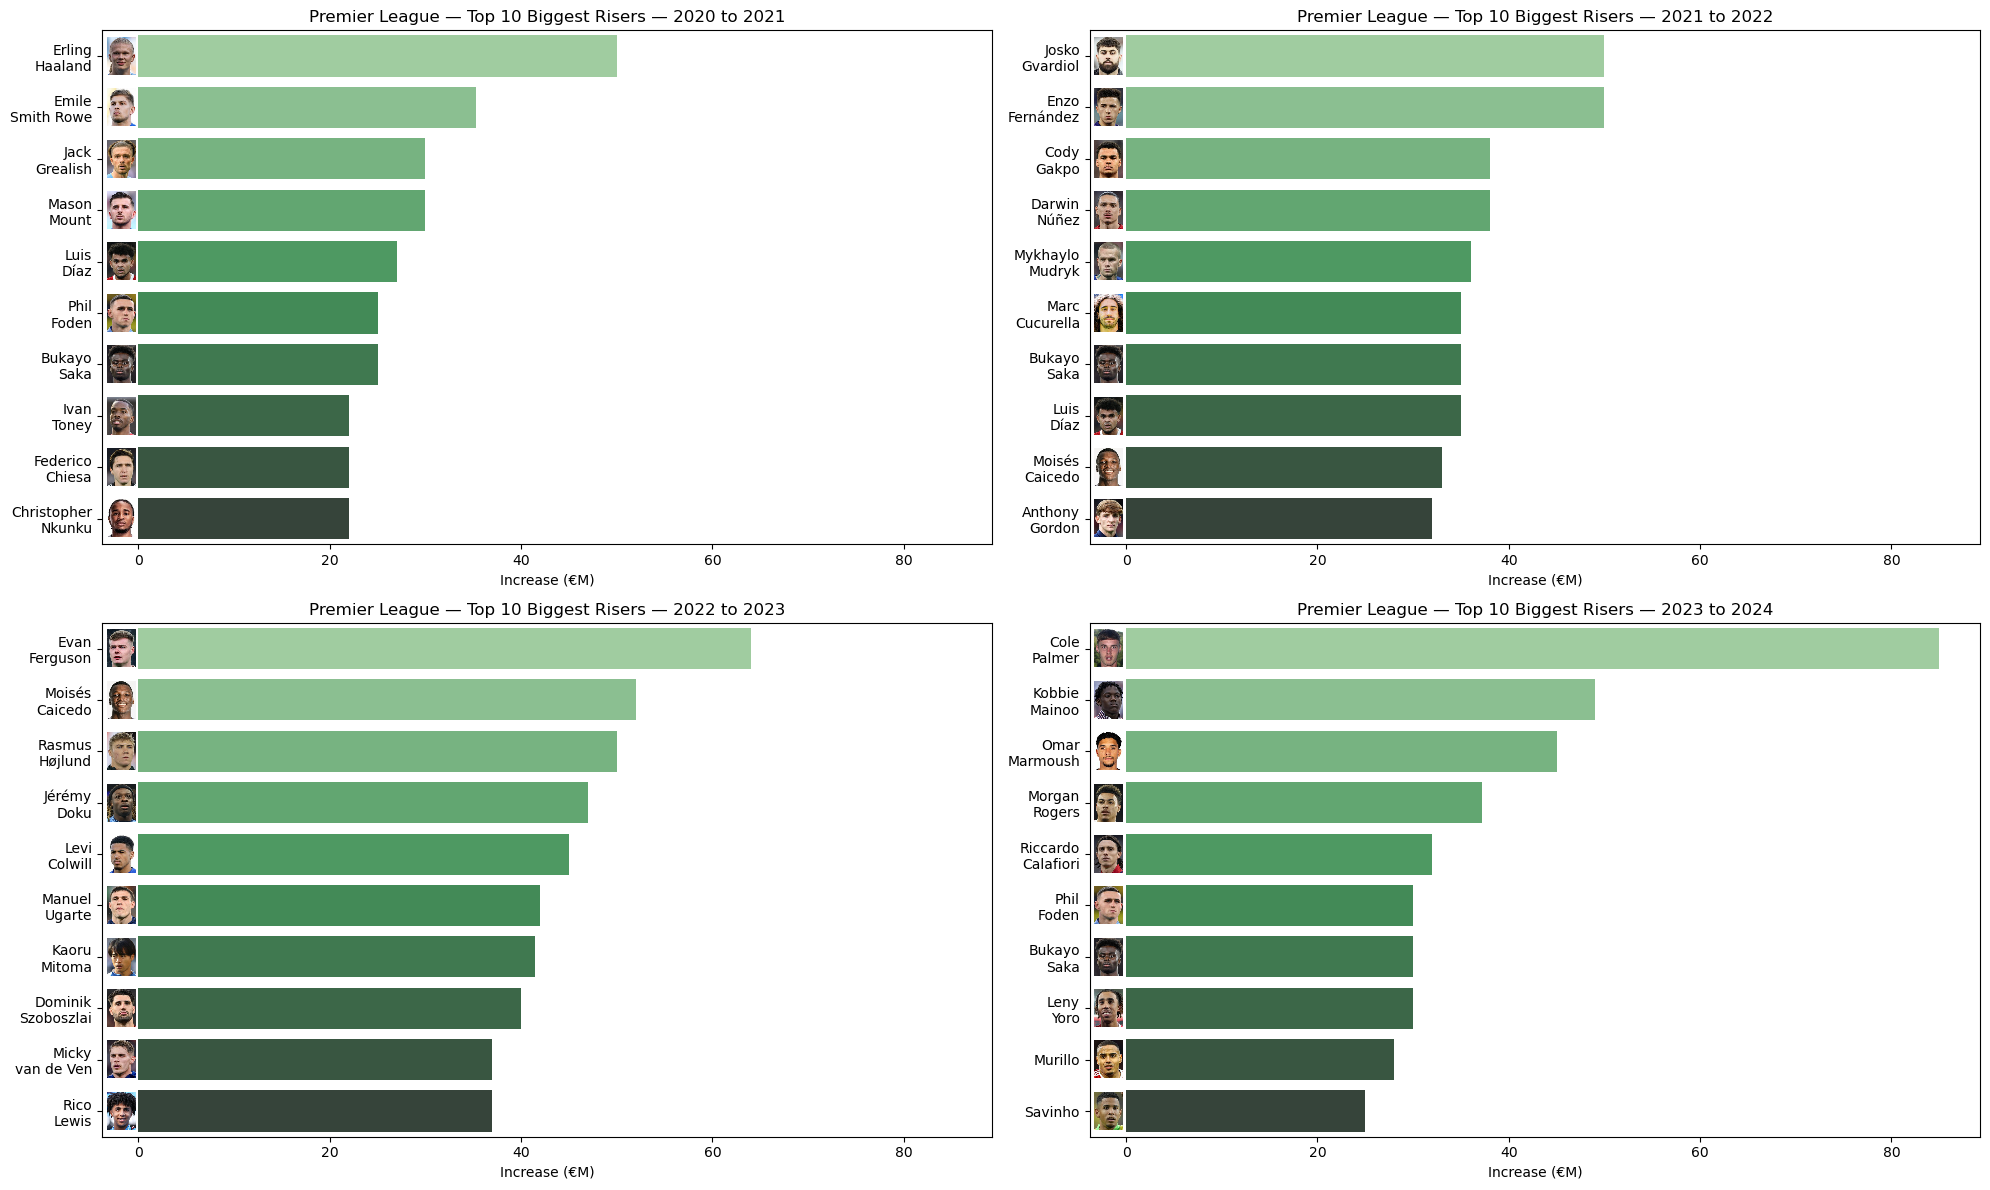

In [26]:
def plot_risers_grid(yearly_deltas, league_name='Premier League', years=[2021, 2022, 2023, 2024], 
                     players_df=None):
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    
    all_risers = []
    for year in years:
        risers = yearly_deltas[yearly_deltas['year'] == year].nlargest(10, 'delta_millions')
        all_risers.append(risers)
    all_risers_df = pd.concat(all_risers)
    global_max = all_risers_df['delta_millions'].max()

    for idx, year in enumerate(years):
        risers = yearly_deltas[yearly_deltas['year'] == year].nlargest(10, 'delta_millions')
        risers = risers.merge(players_df[['player_id', 'image_url']], on='player_id', how='left')
        
        risers['name_wrapped'] = risers['name'].apply(lambda x: x.replace(' ', '\n', 1))
        
        sns.barplot(data=risers, x='delta_millions', y='name_wrapped', palette='Greens_d', ax=axes[idx])
        axes[idx].set_title(f'{league_name} — Top 10 Biggest Risers — {year-1} to {year}')
        axes[idx].set_xlabel('Increase (€M)')
        axes[idx].set_ylabel('')
        
        axes[idx].set_xlim(-3.8, global_max * 1.05)
        
        risers = risers.reset_index(drop=True)
        for i, row in risers.iterrows():
            with urlopen(row['image_url']) as url:
                img = Image.open(url)
                imagebox = OffsetImage(img, zoom=0.15)
                ab = AnnotationBbox(
                    imagebox,
                    (-0.3, i),
                    xycoords='data',
                    box_alignment=(1, 0.5),
                    frameon=False
                )
                axes[idx].add_artist(ab)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/eda_plots/risers_{league_name.replace(" ", "_").lower()}_all_years.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
yearly_deltas = get_yearly_deltas(league_id='GB1')
plot_risers_grid(yearly_deltas, league_name='Premier League', players_df=players)

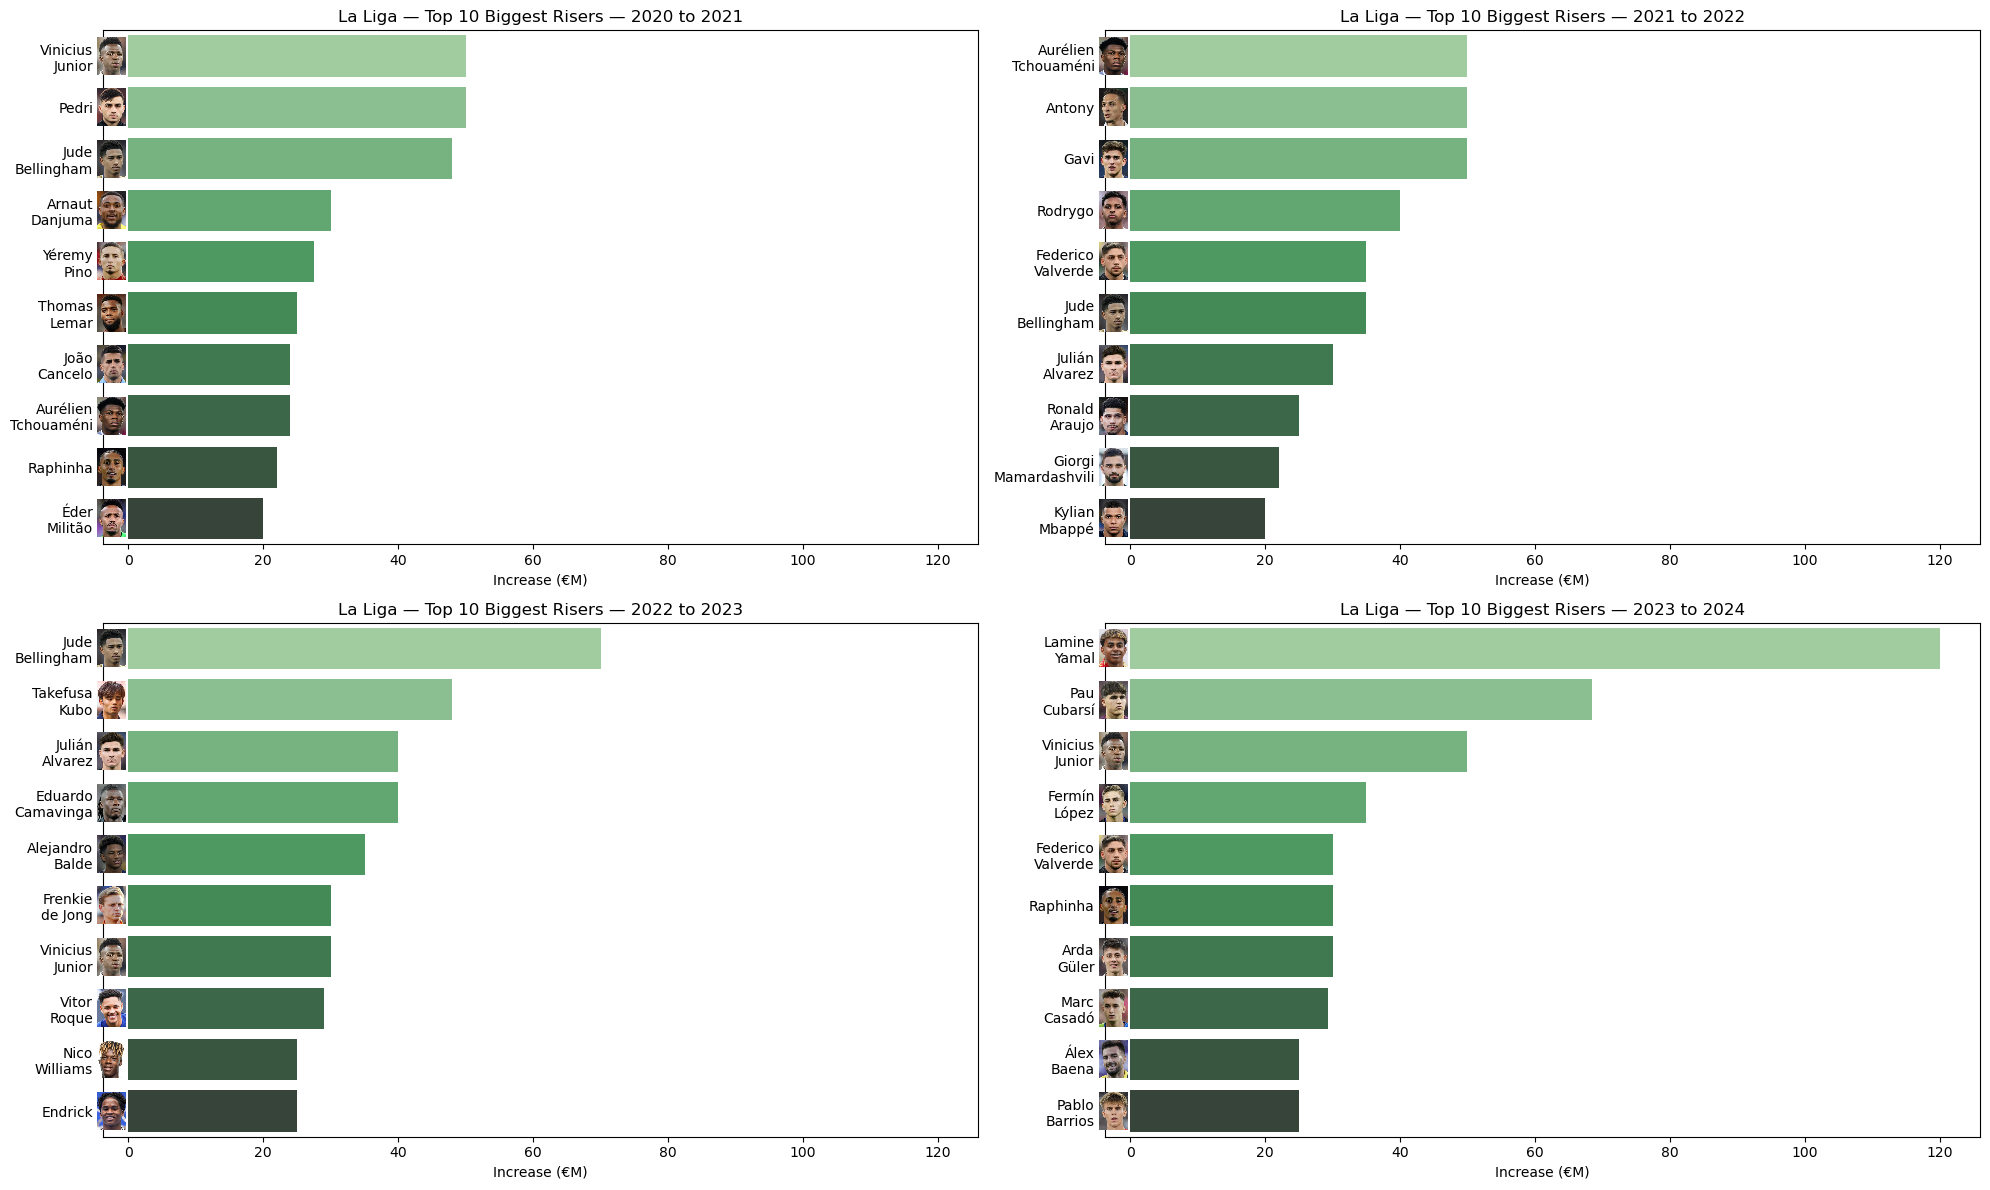

In [27]:
yearly_deltas = get_yearly_deltas(league_id='ES1')
plot_risers_grid(yearly_deltas, league_name='La Liga', players_df=players)

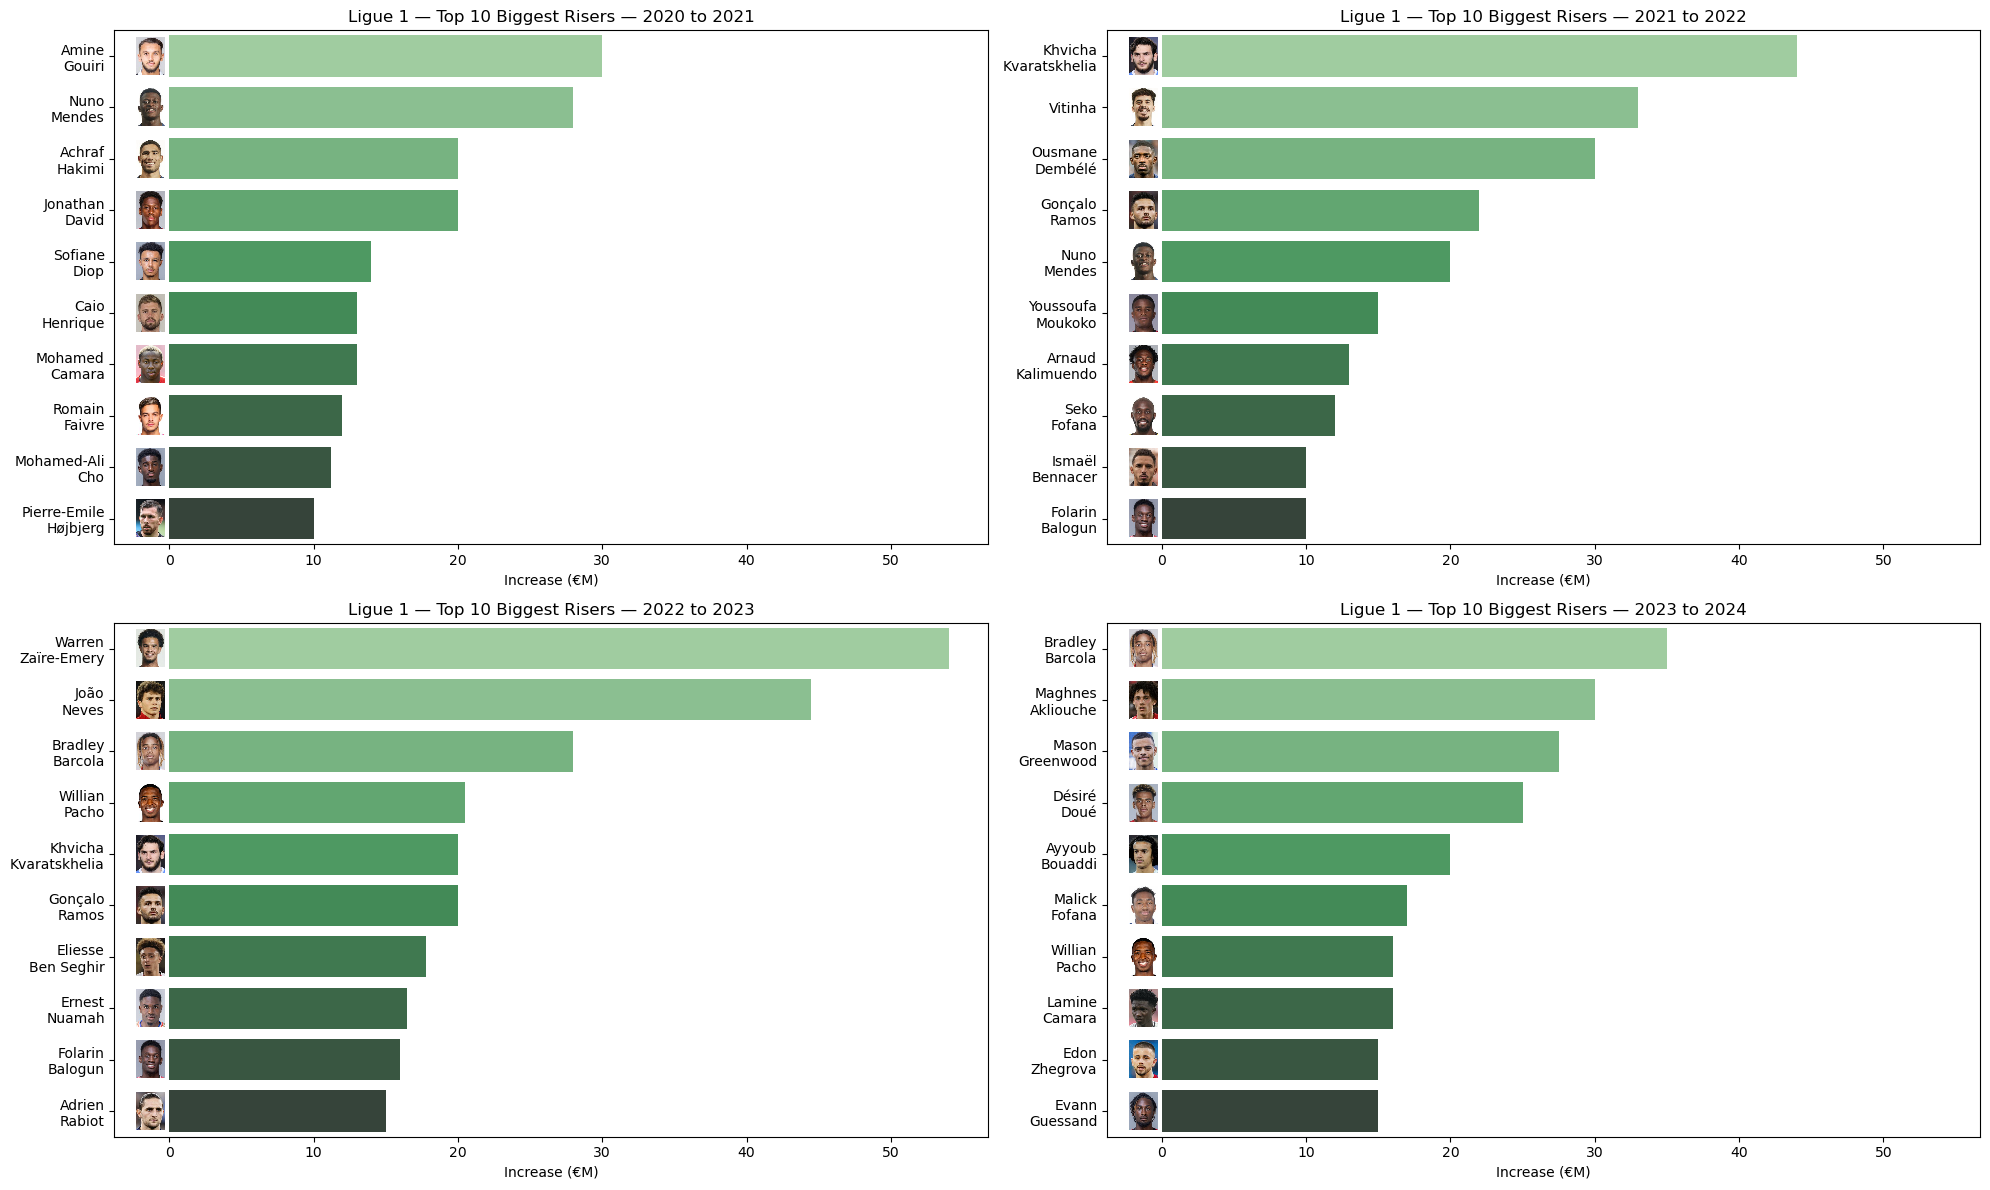

In [28]:
yearly_deltas = get_yearly_deltas(league_id='FR1')
plot_risers_grid(yearly_deltas, league_name='Ligue 1', players_df=players)

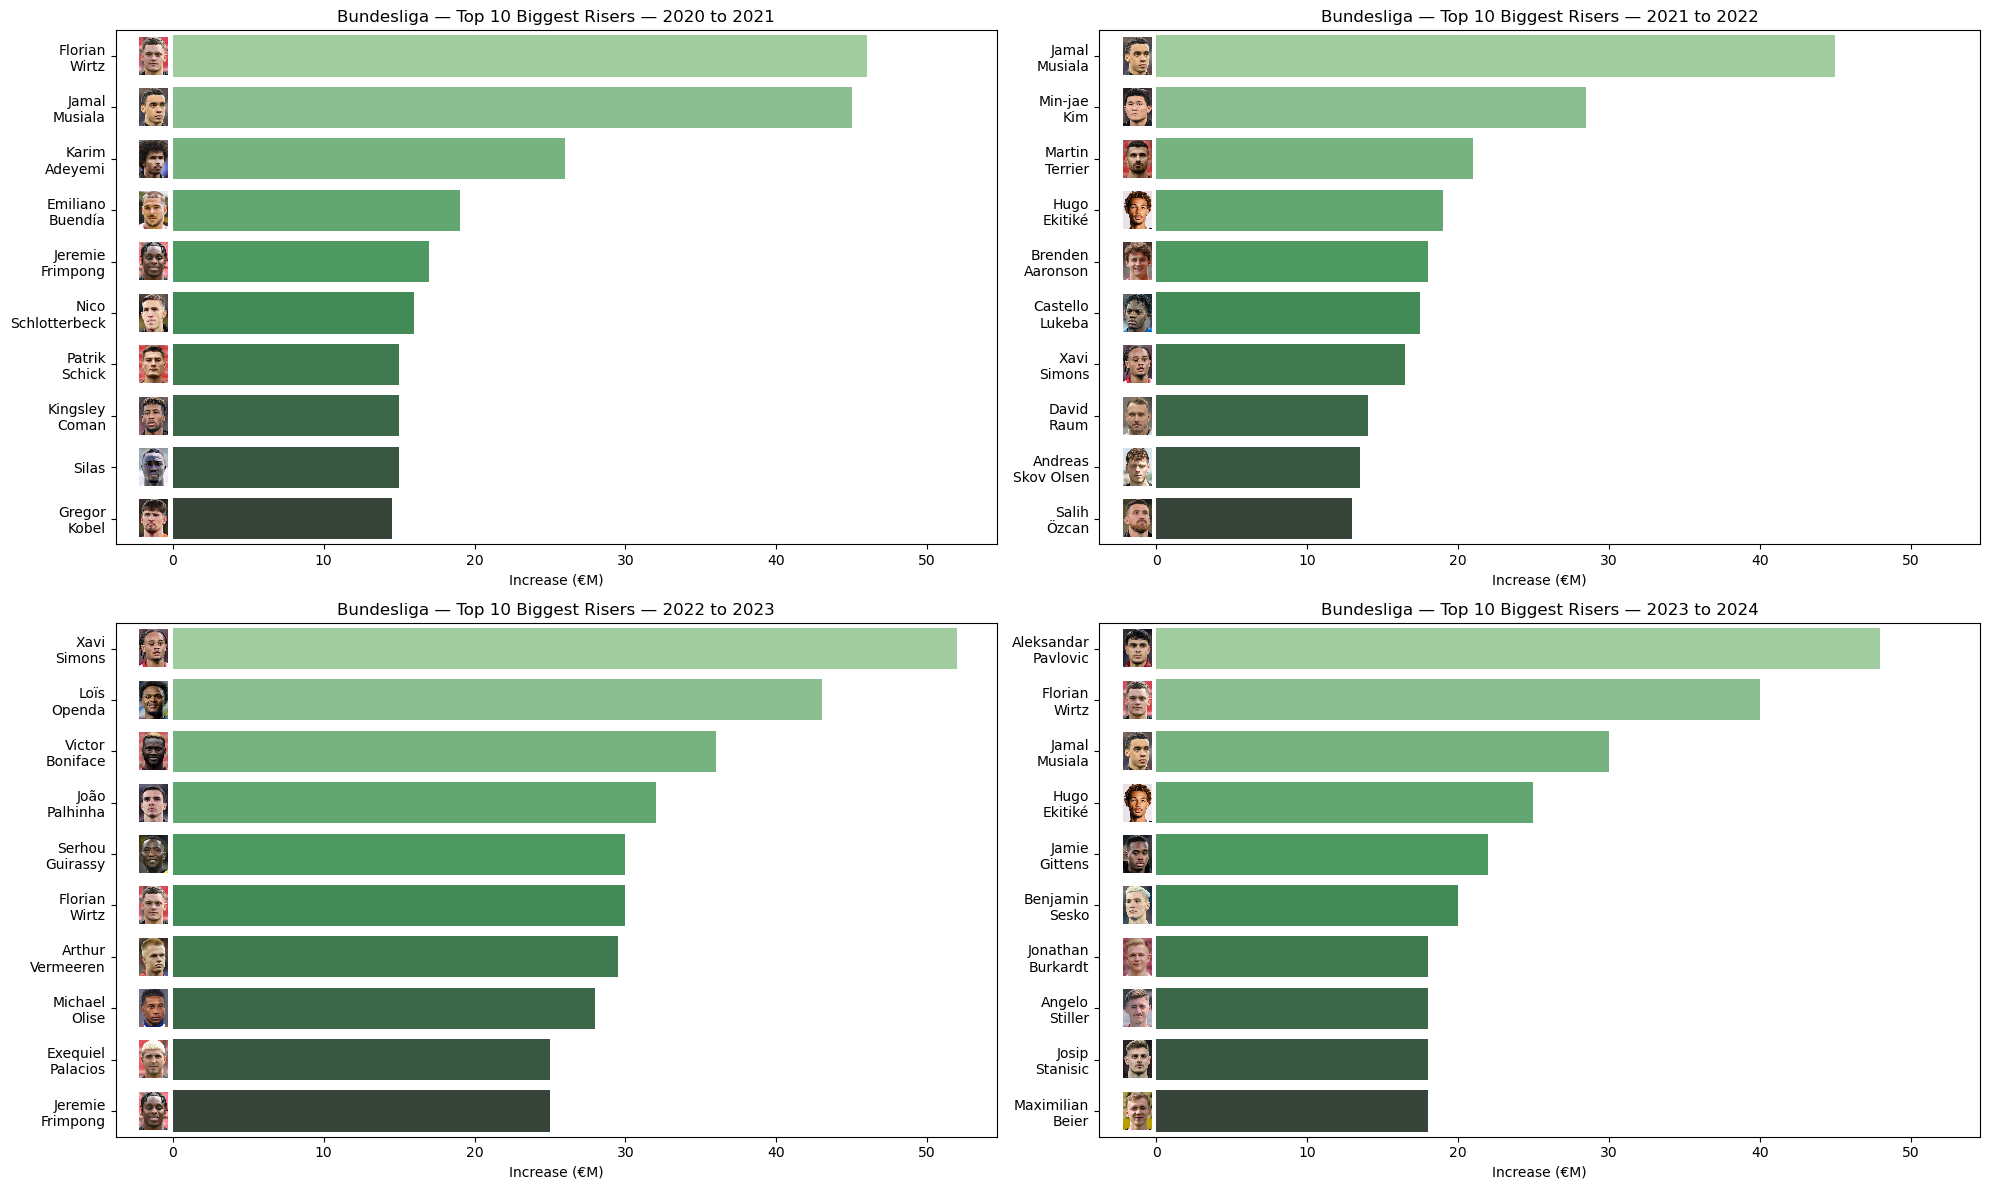

In [29]:
yearly_deltas = get_yearly_deltas(league_id='L1')
plot_risers_grid(yearly_deltas, league_name='Bundesliga', players_df=players)

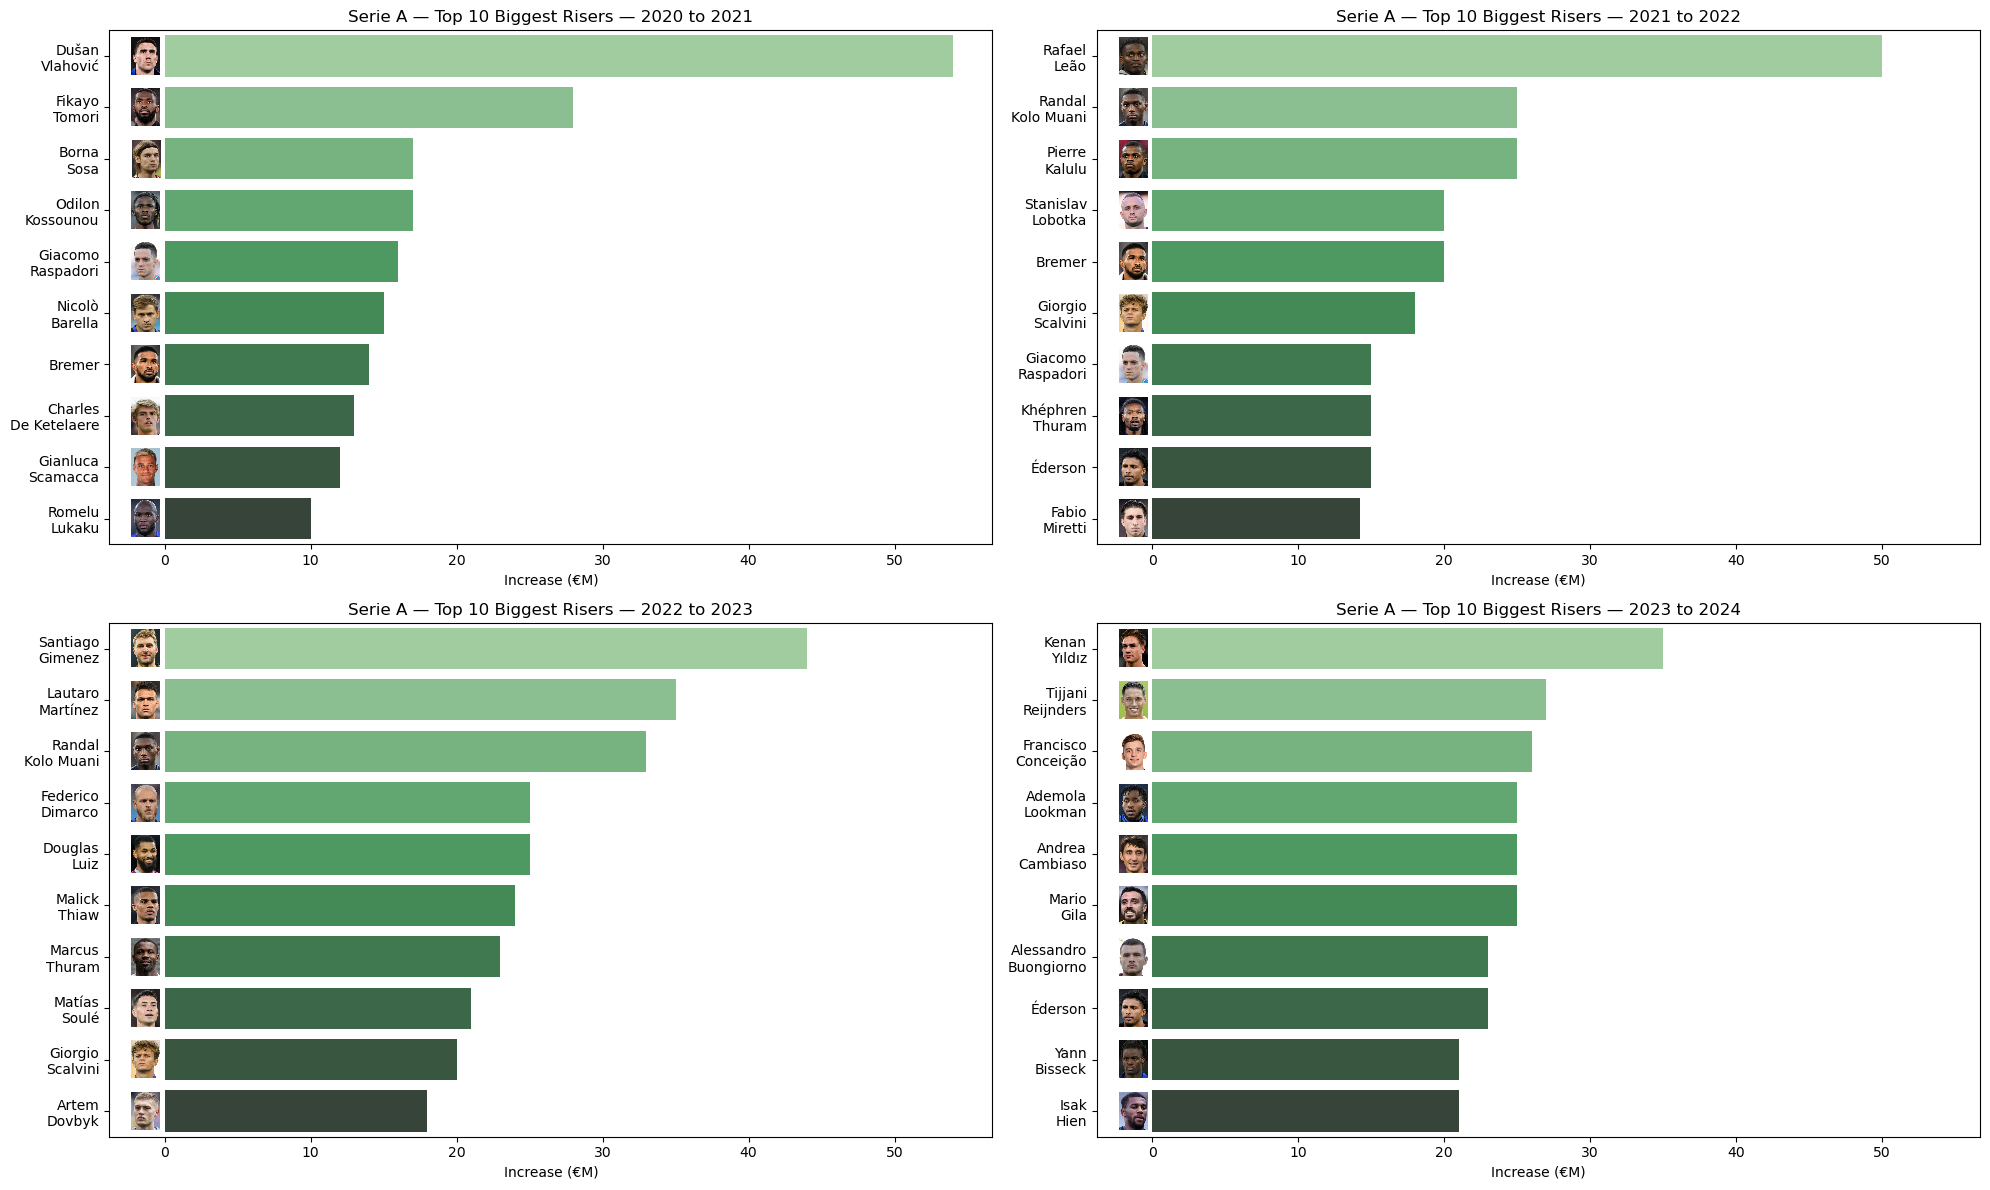

In [30]:
yearly_deltas = get_yearly_deltas(league_id='IT1')
plot_risers_grid(yearly_deltas, league_name='Serie A', players_df=players)

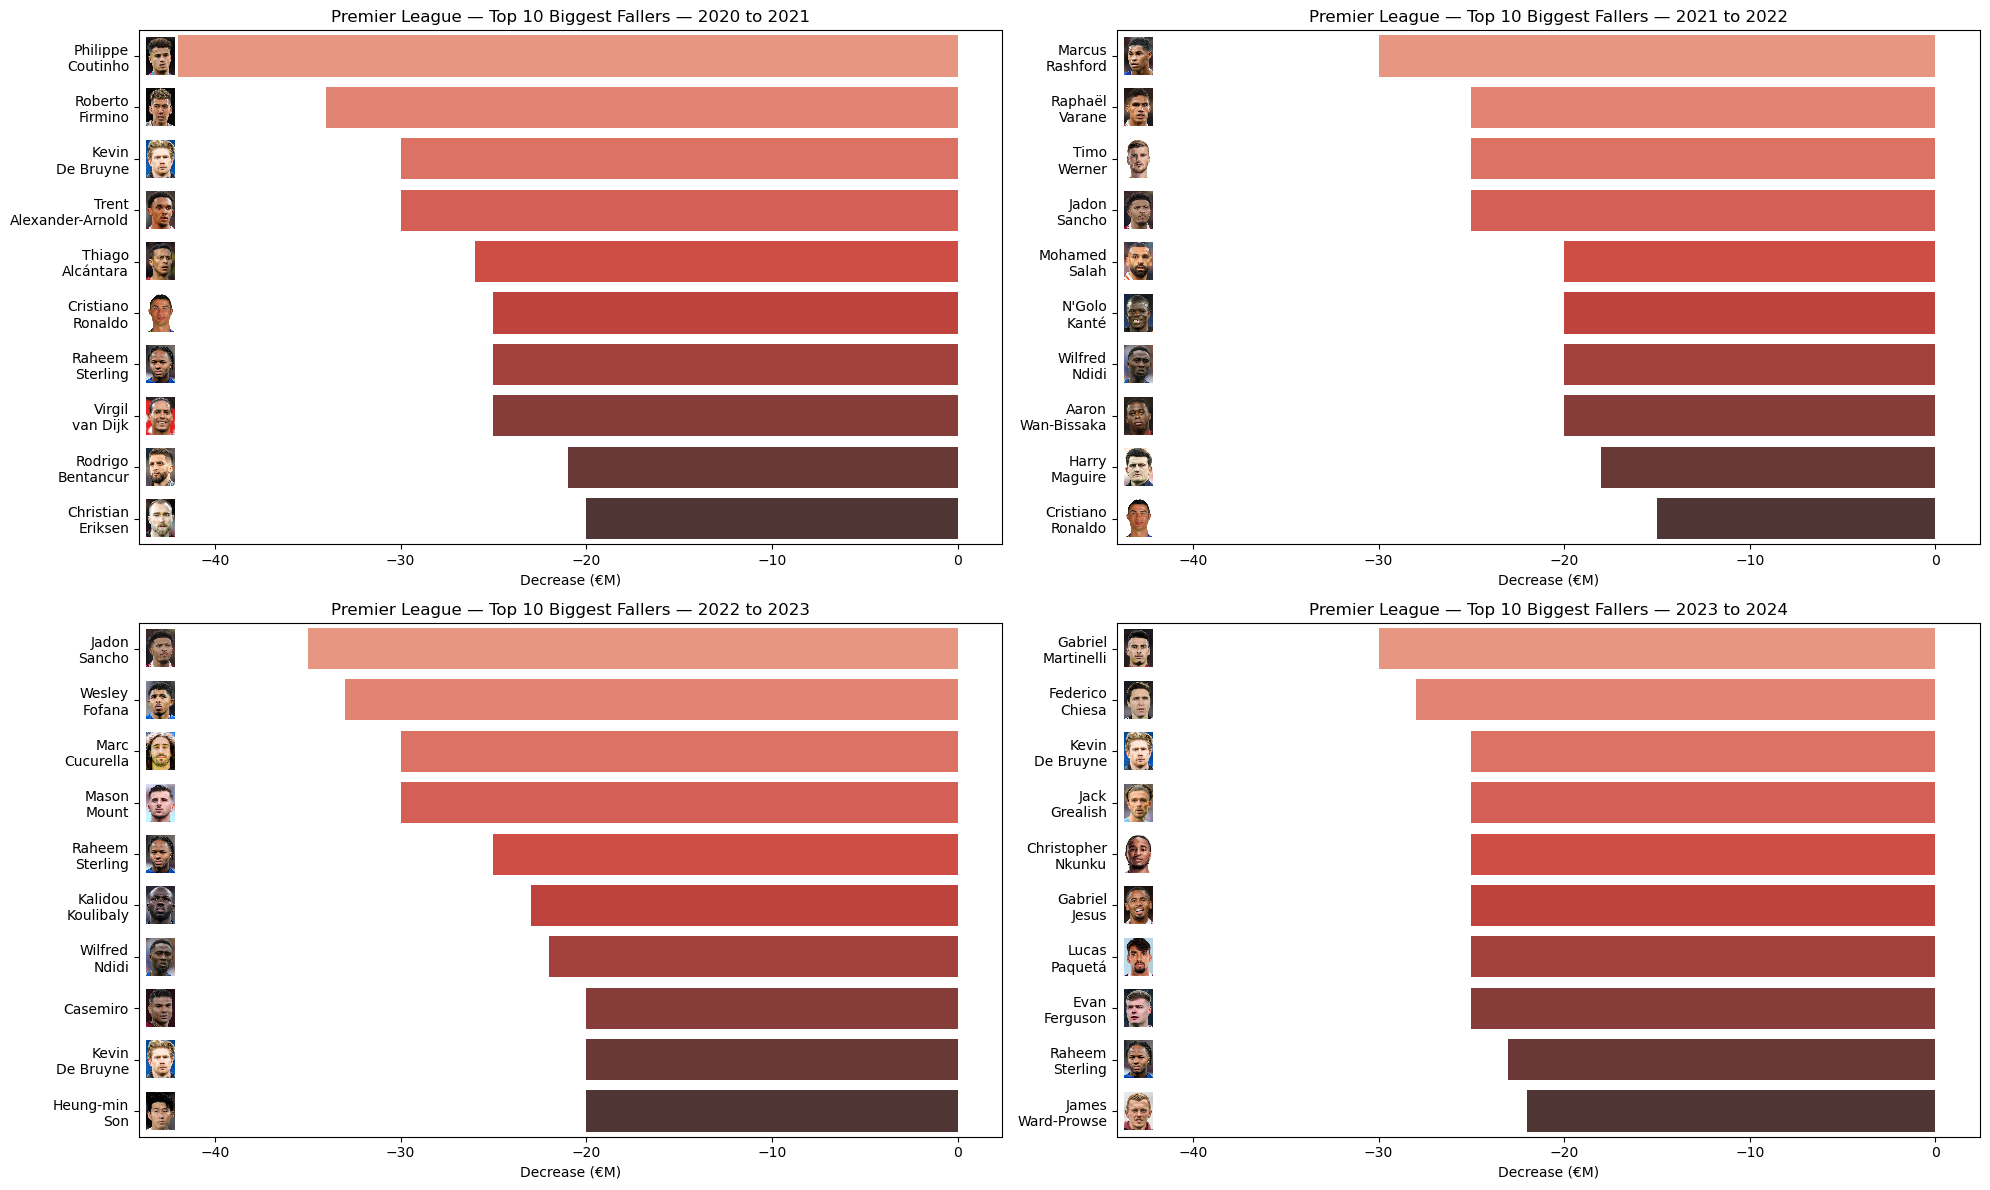

In [31]:
def plot_fallers_grid(yearly_deltas, league_name='Premier League', years=[2021, 2022, 2023, 2024],
                      players_df=None):
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    
    all_fallers = []
    for year in years:
        fallers = yearly_deltas[yearly_deltas['year'] == year].nsmallest(10, 'delta_millions')
        all_fallers.append(fallers)
    all_fallers_df = pd.concat(all_fallers)
    global_min = all_fallers_df['delta_millions'].min()
    
    for idx, year in enumerate(years):
        fallers = yearly_deltas[yearly_deltas['year'] == year].nsmallest(10, 'delta_millions')
        fallers = fallers.merge(players_df[['player_id', 'image_url']], on='player_id', how='left')
        
        fallers['name_wrapped'] = fallers['name'].apply(lambda x: x.replace(' ', '\n', 1))
        
        sns.barplot(data=fallers, x='delta_millions', y='name_wrapped', palette='Reds_d', ax=axes[idx])
        axes[idx].set_title(f'{league_name} — Top 10 Biggest Fallers — {year-1} to {year}')
        axes[idx].set_xlabel('Decrease (€M)')
        axes[idx].set_ylabel('')
        
        axes[idx].set_xlim(global_min * 1.05, 2.4)
        
        fallers = fallers.reset_index(drop=True)
        for i, row in fallers.iterrows():
            with urlopen(row['image_url']) as url:
                img = Image.open(url)
                imagebox = OffsetImage(img, zoom=0.15)
                ab = AnnotationBbox(
                    imagebox,
                    (-43.7, i),
                    xycoords='data',
                    box_alignment=(0, 0.5),
                    frameon=False
                )
                axes[idx].add_artist(ab)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/eda_plots/fallers_{league_name.replace(" ", "_").lower()}_all_years.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

yearly_deltas = get_yearly_deltas(league_id='GB1')
plot_fallers_grid(yearly_deltas, league_name='Premier League', players_df=players)

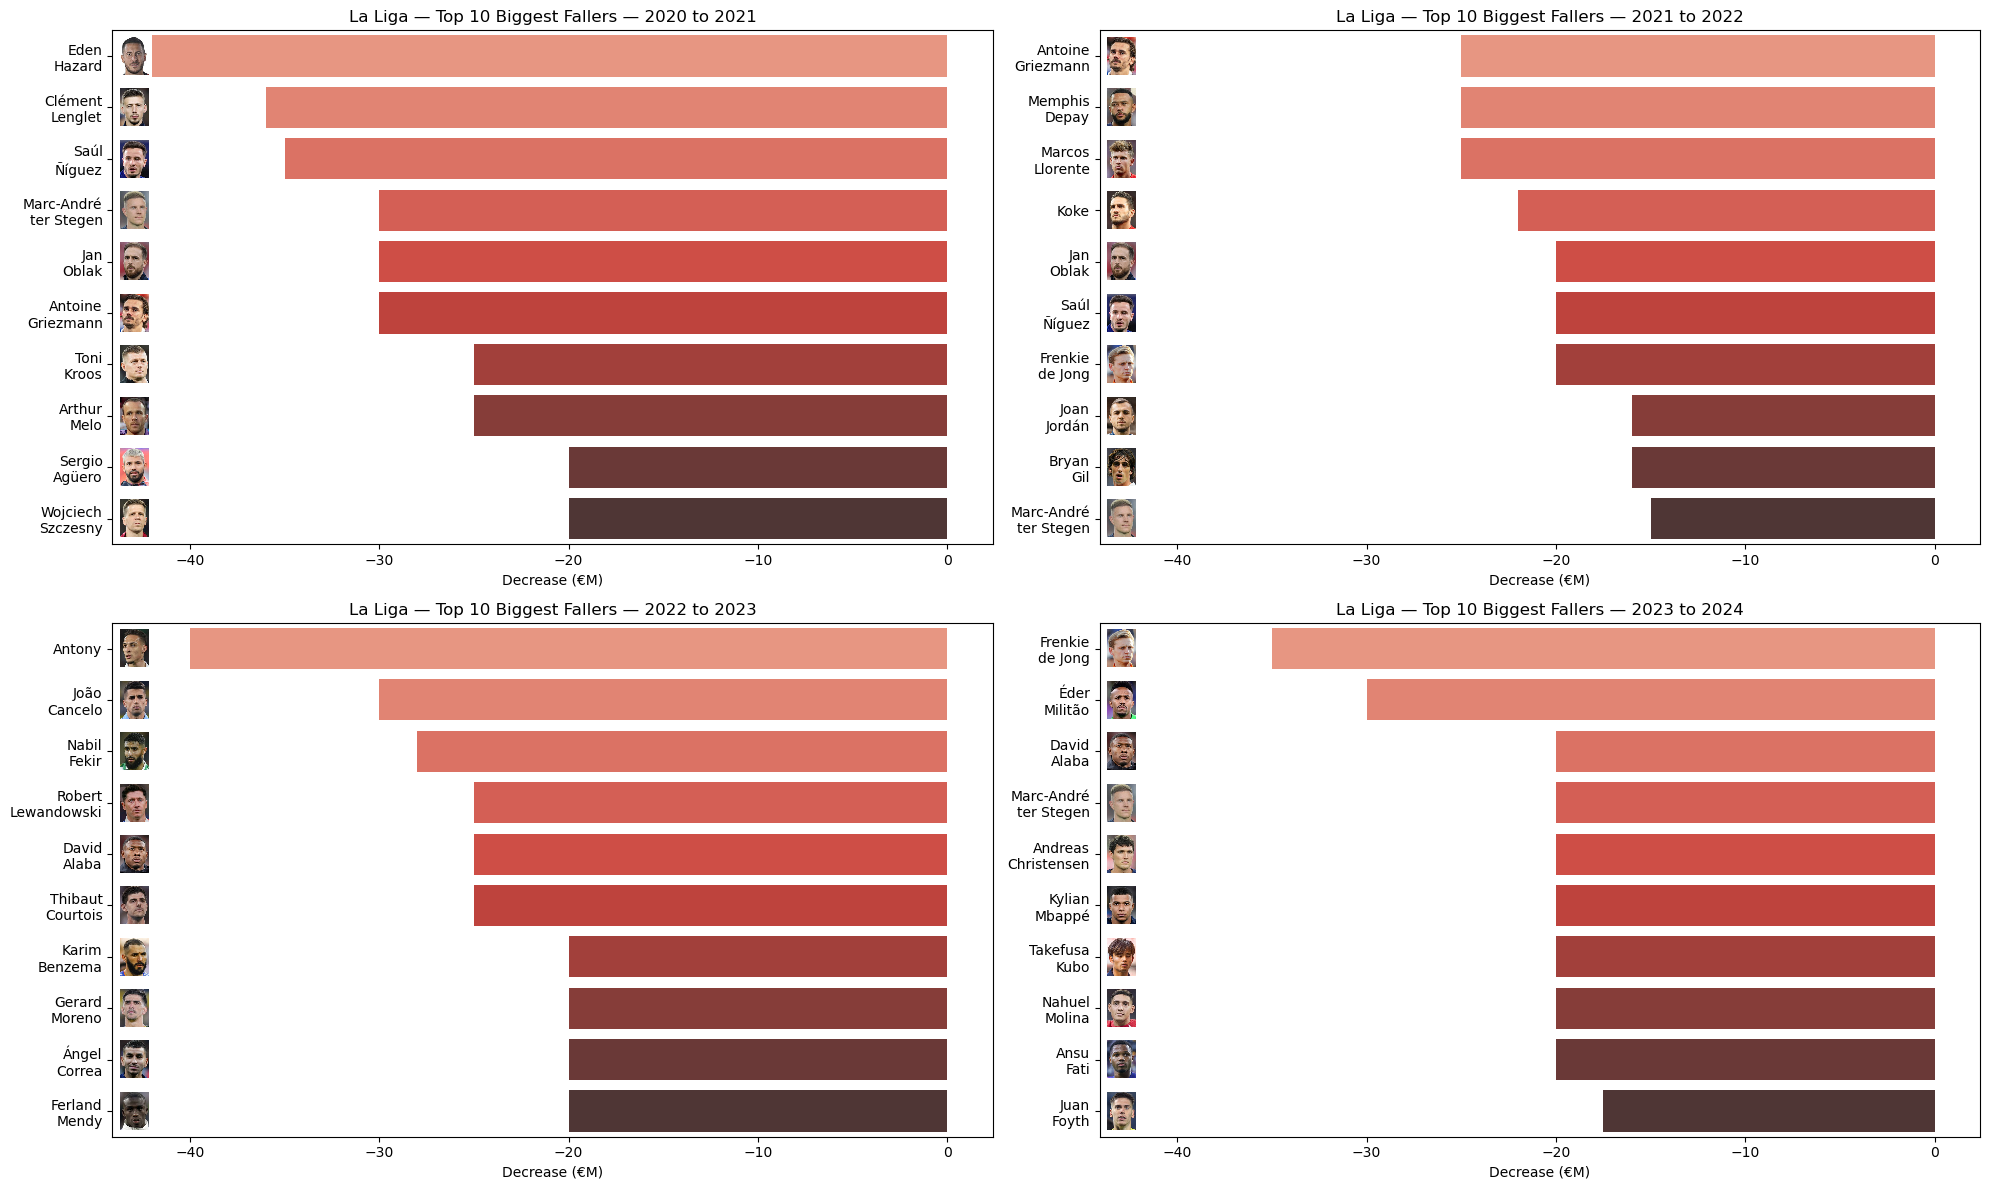

In [32]:
yearly_deltas = get_yearly_deltas(league_id='ES1')
plot_fallers_grid(yearly_deltas, league_name='La Liga', players_df=players)

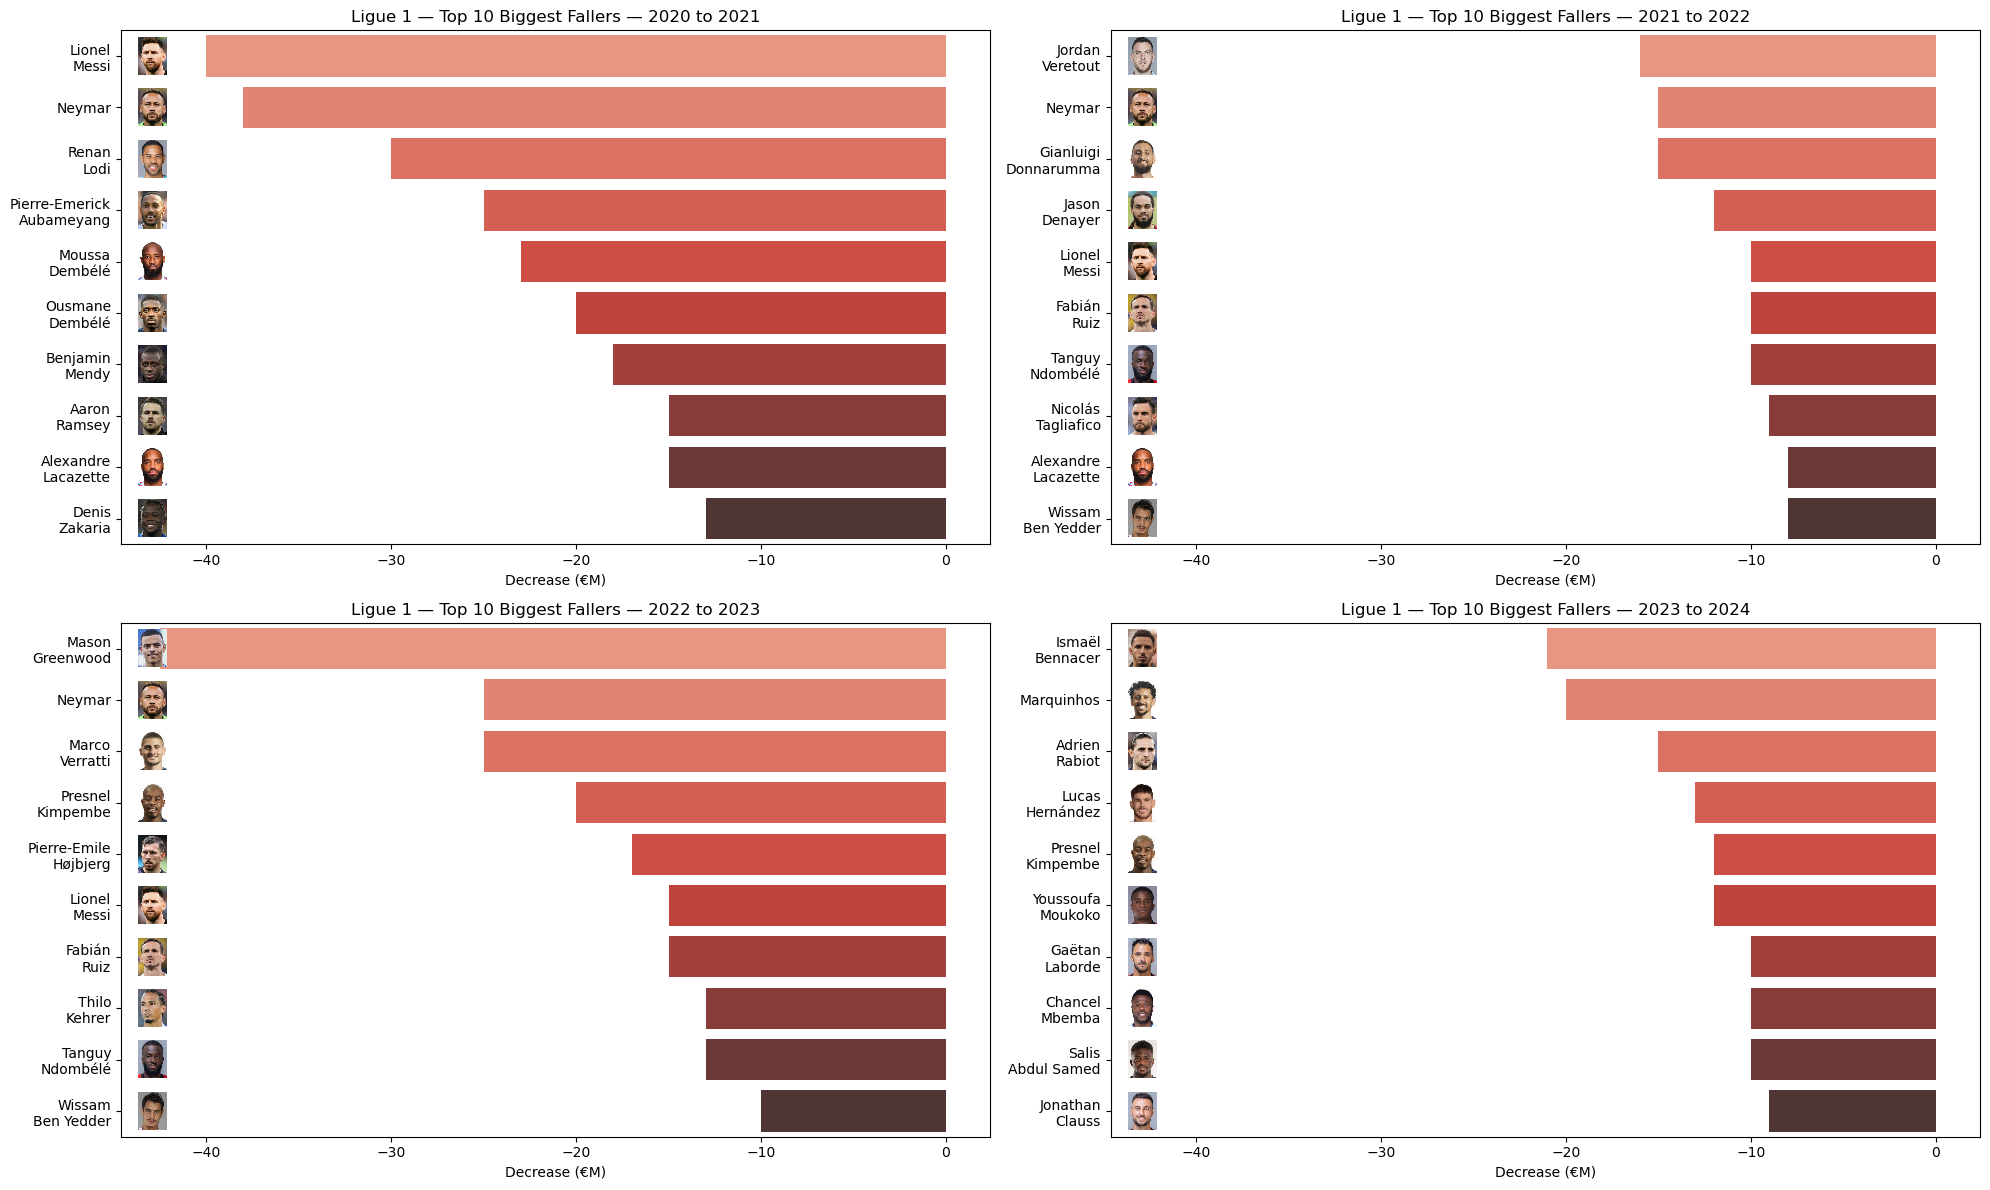

In [33]:
yearly_deltas = get_yearly_deltas(league_id='FR1')
plot_fallers_grid(yearly_deltas, league_name='Ligue 1', players_df=players)

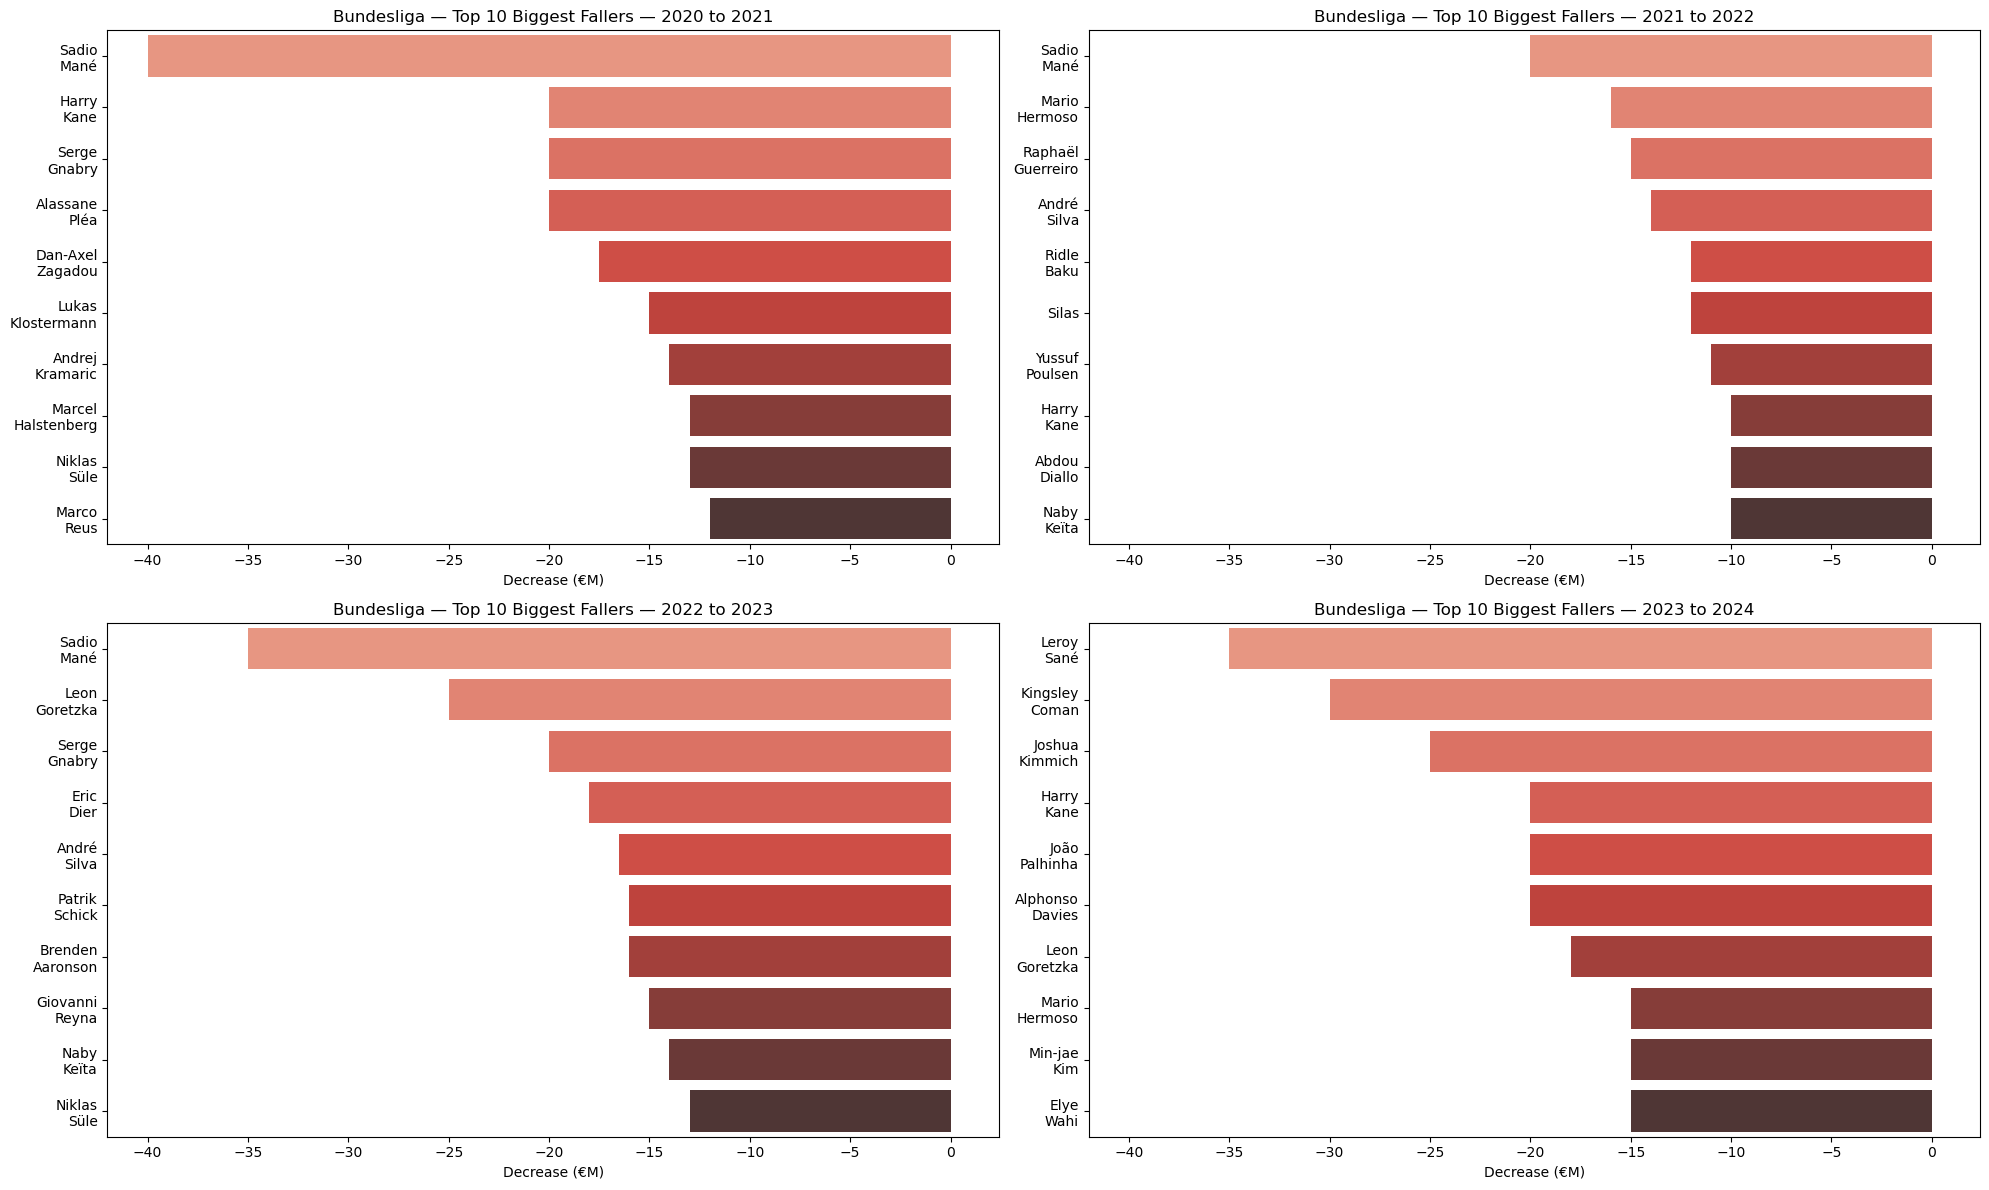

In [34]:
yearly_deltas = get_yearly_deltas(league_id='L1')
plot_fallers_grid(yearly_deltas, league_name='Bundesliga', players_df=players)

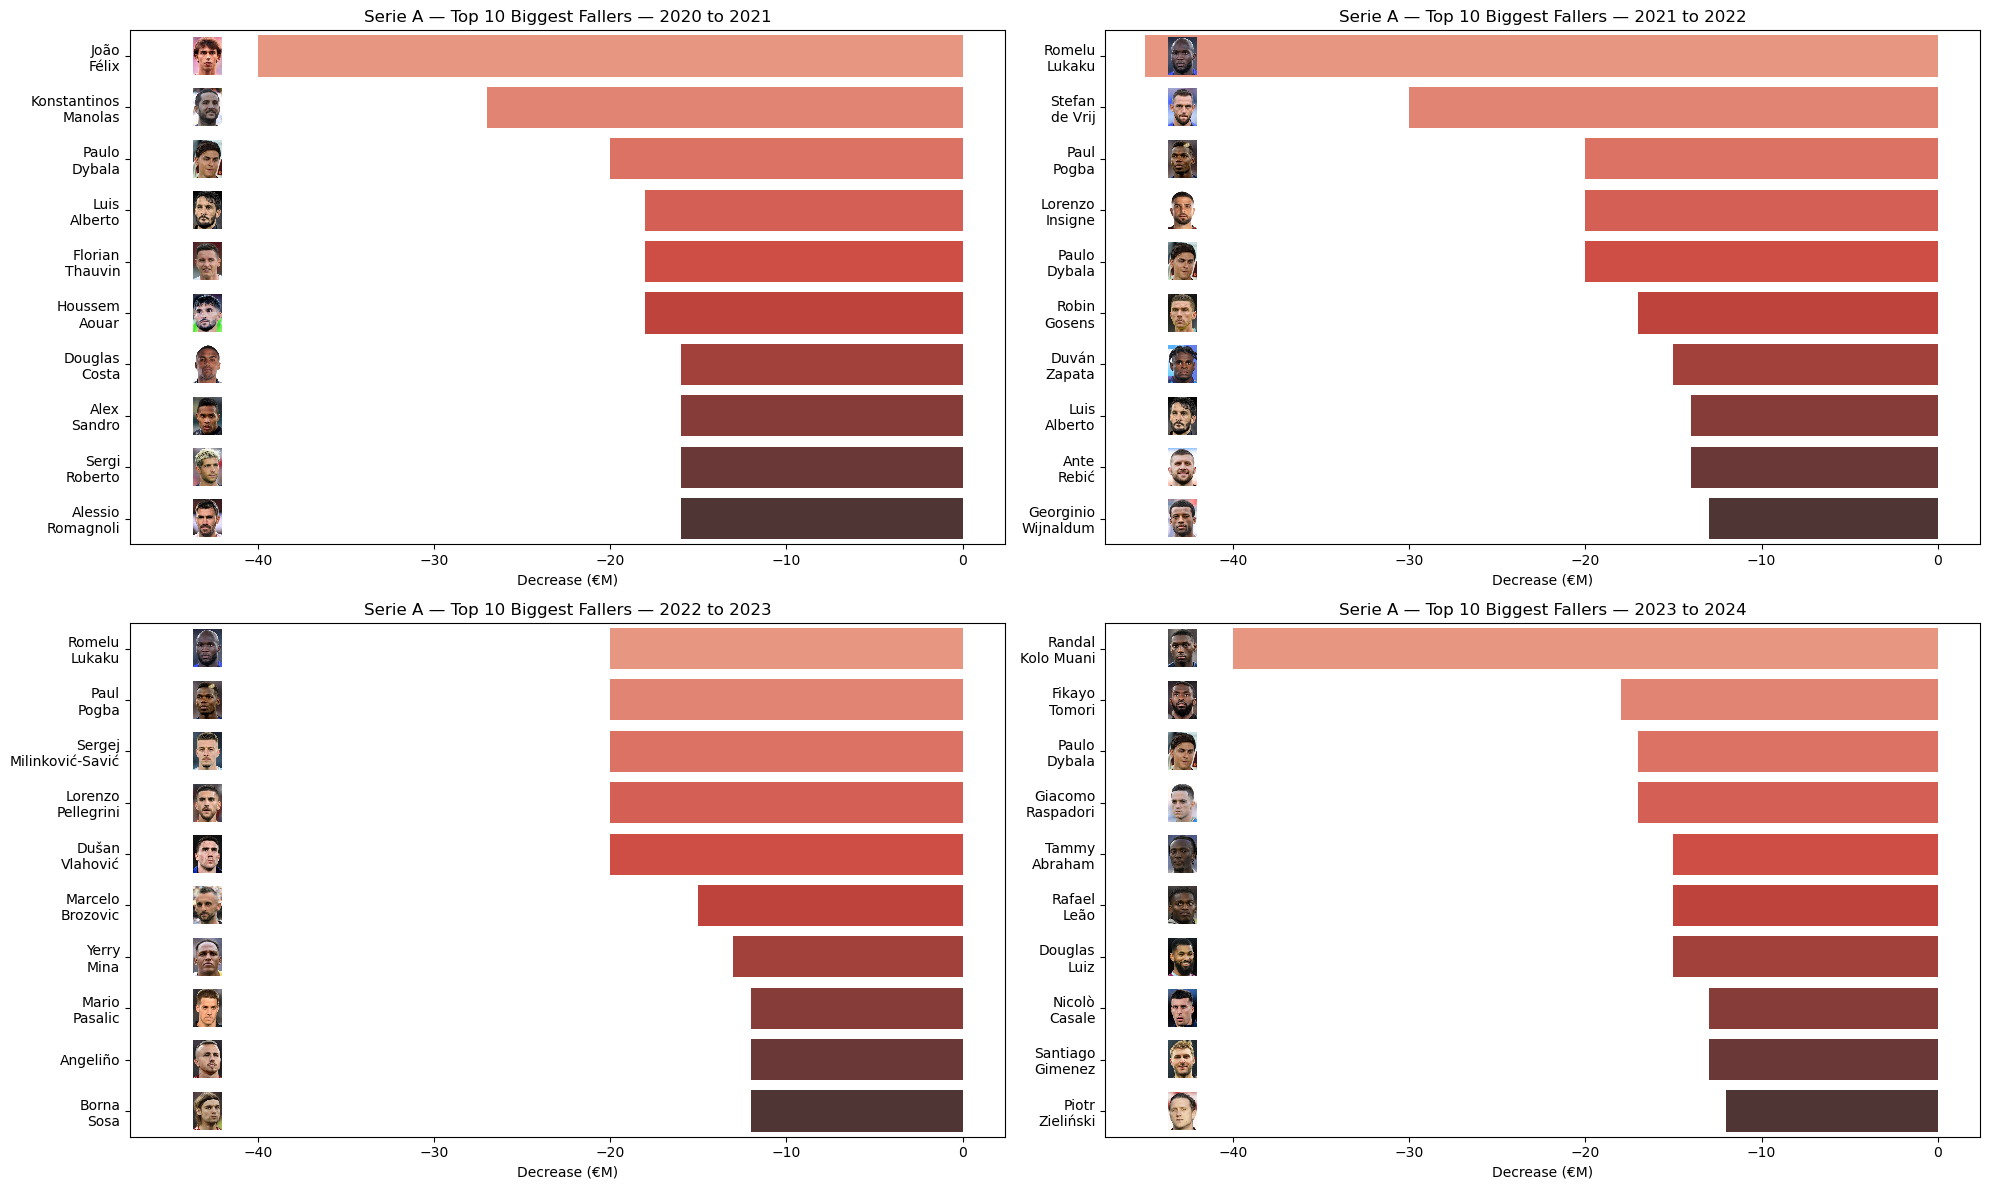

In [35]:
yearly_deltas = get_yearly_deltas(league_id='IT1')
plot_fallers_grid(yearly_deltas, league_name='Serie A', players_df=players)

In [36]:
pl_vals = valuations[valuations['player_club_domestic_competition_id'] == 'FR1']

pl_vals['date'] = pd.to_datetime(pl_vals['date'])
pl_vals['year'] = pl_vals['date'].dt.year

yearly_vals = pl_vals.sort_values('date').groupby(['player_id', 'year'])['market_value_in_eur'].last().reset_index()

yearly_vals = yearly_vals.sort_values(['player_id', 'year'])
yearly_vals['delta_eur'] = yearly_vals.groupby('player_id')['market_value_in_eur'].diff()
yearly_vals['delta_millions'] = yearly_vals['delta_eur'] / 1e6

yearly_vals = yearly_vals.merge(players[['player_id', 'name']], on='player_id', how='left')

yearly_deltas = yearly_vals[yearly_vals['year'].between(2021, 2024)].dropna(subset=['delta_millions'])

In [37]:
fbref_big5 = pd.read_csv('../data/raw/big5_leagues_stats.csv')

def parse_scorer(scorer_str):
    if pd.isna(scorer_str):
        return pd.Series([None, None])
    parts = scorer_str.rsplit(' - ', 1)
    name = parts[0].strip() if len(parts) > 1 else None
    goals = int(parts[1]) if len(parts) > 1 else None
    return pd.Series([name, goals])

fbref_big5[['scorer_name', 'goals_scored']] = fbref_big5['Top Team Scorer'].apply(parse_scorer)

print("Parsed data:", fbref_big5[['Squad', 'scorer_name', 'goals_scored']].head(10))

Parsed data:              Squad         scorer_name  goals_scored
0        Paris S-G     Ousmane Dembélé            21
1    Bayern Munich          Harry Kane            26
2        Barcelona  Robert Lewandowski            27
3        Liverpool       Mohamed Salah            29
4      Real Madrid       Kylian Mbappé            31
5           Napoli       Romelu Lukaku            14
6            Inter       Marcus Thuram            14
7       Leverkusen       Patrik Schick            21
8  Atlético Madrid   Alexander Sørloth            20
9         Atalanta       Mateo Retegui            25
